# Paper 01 — Ghanem, Sant'Anna & Wüthrich: *Selection and Parallel Trends*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afrtrivi1120/causal-inference-papers-explainer/blob/master/papers/did/01-ghanem-santanna-wuthrich-selection-parallel-trends/simulation.ipynb)

See this folder's `README.md` for the 12-section explainer. This notebook is the runnable companion.

**What this simulation shows.** Parallel trends (PT) is a restriction on *how units select into treatment*, not a statement about trends alone. We run two scenarios with the same constant treatment effect:

- **Scenario A** — selection on time-invariant levels only (the gain-driving factor is independent of the untreated trend). PT holds, and the 2×2 DiD estimator recovers the true ATT on average.
- **Scenario B** — Roy-style selection on expected gains, where the gain-driving factor *does* correlate with the untreated trend. PT silently fails, and 2×2 DiD is biased even though the per-unit treatment effect is constant.

The punchline: selection-on-gains alone does not break DiD. Selection on a gain-driving factor that also moves the untreated trend does.

In [1]:
# Suppress anaconda-local UserWarnings before any import that touches pandas internals.
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Colab: the scientific Python stack is pre-installed, so nothing to pip install here.
# Locally: `pip install -r requirements.txt` from the repo root first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Pin seed (same value the retired R simulation used; numpy's MT19937 stream
# differs from R's Mersenne Twister, so numerical values will differ across
# languages — the qualitative pattern is what reproduces).
SEED = 20260421
rng = np.random.default_rng(SEED)

# Print versions so a reader who gets different numbers can diagnose.
import sys
print(f'Python       {sys.version.split()[0]}')
print(f'numpy        {np.__version__}')
print(f'pandas       {pd.__version__}')
print(f'matplotlib   {plt.matplotlib.__version__}')
import statsmodels; print(f'statsmodels  {statsmodels.__version__}')

Python       3.11.5
numpy        1.26.4
pandas       3.0.2
matplotlib   3.10.8
statsmodels  0.14.6


## Parameters

Tunable constants. `N_SIM` controls Monte Carlo draws — drop to 50 for quick iteration.

In [2]:
N_SIM  = 300    # Monte Carlo draws per scenario
N      = 2000   # Units per draw
TAU    = 1.5    # True per-unit gain base. With v ~ N(0,1) this implies
                # P(D=1) ~ Phi(1.5) ~ 0.93 — an intentionally imbalanced
                # split that magnifies the Roy-selection bias.
LAMBDA = 1.0    # Spread of individual gains around TAU
GAMMA  = 0.8    # Common time effect in Y(0,t=2) - Y(0,t=1)
SIGMA  = 0.5    # Idiosyncratic noise sd

## Data-generating process

`rho` controls the correlation between the gain-driving unobserved $v$ and the untreated trend in period 2. `rho = 0` ⇒ PT holds; `rho > 0` ⇒ Roy selection silently breaks PT because treated units (high $v$) also have a steeper untreated trend.

The bias is the product of two things: $\rho > 0$ ties the untreated trend to $v$, AND treatment selects on $v$. Remove either ingredient and DiD is unbiased.

In [3]:
def draw_dgp(rho, rng):
    """One draw of the DGP. Returns a DataFrame of unit-level outcomes + Y(0) counterfactual."""
    alpha = rng.normal(0, 1, N)            # unit-level heterogeneity (level)
    v     = rng.normal(0, 1, N)            # drives individual treatment gain
    eps1  = rng.normal(0, SIGMA, N)        # period-1 noise
    eps2  = rng.normal(0, SIGMA, N)        # period-2 noise

    y0_t1 = alpha + eps1
    y0_t2 = alpha + GAMMA + rho * v + eps2

    gain  = TAU + LAMBDA * v
    y1_t2 = y0_t2 + gain

    # Roy-style selection: treat if expected gain (plus mild noise) is positive.
    D     = ((gain + rng.normal(0, 0.3, N)) > 0).astype(int)

    y_t1  = y0_t1
    y_t2  = np.where(D == 1, y1_t2, y0_t2)

    return pd.DataFrame({
        "id": np.arange(N),
        "D": D,
        "gain": gain,
        "y_t1": y_t1,
        "y_t2": y_t2,
        "y0_t1": y0_t1,
        "y0_t2": y0_t2,
    })


def run_once(rho, rng):
    """Fit the canonical 2x2 DiD on one draw. Returns (att_true, did_estimate, bias)."""
    dgp = draw_dgp(rho, rng)
    att_true = dgp.loc[dgp["D"] == 1, "gain"].mean()

    long = pd.DataFrame({
        "id":     np.tile(dgp["id"].values, 2),
        "period": np.concatenate([np.ones(N, dtype=int), 2 * np.ones(N, dtype=int)]),
        "post":   np.concatenate([np.zeros(N, dtype=int), np.ones(N, dtype=int)]),
        "treat":  np.tile(dgp["D"].values, 2),
        "y":      np.concatenate([dgp["y_t1"].values, dgp["y_t2"].values]),
    })

    fit = smf.ols("y ~ treat * post", data=long).fit()
    dd  = fit.params["treat:post"]

    return att_true, dd, dd - att_true

## Monte Carlo

Run each scenario `N_SIM` times and summarize.

In [4]:
def run_scenario(rho, label):
    print(f"Running {label} (rho = {rho}) ... ", end="", flush=True)
    out = np.array([run_once(rho, rng) for _ in range(N_SIM)])
    print("done.")
    return out   # shape (N_SIM, 3) — columns: att_true, dd, bias


A = run_scenario(0.0, "Scenario A (PT holds)")
B = run_scenario(1.0, "Scenario B (Roy selection)")

summary = pd.DataFrame({
    "scenario":          ["A: PT holds (rho=0)", "B: Roy selection (rho=1)"],
    "mean_true_ATT":     [A[:, 0].mean(), B[:, 0].mean()],
    "mean_DiD_estimate": [A[:, 1].mean(), B[:, 1].mean()],
    "mean_bias":         [A[:, 2].mean(), B[:, 2].mean()],
    "sd_DiD":            [A[:, 1].std(ddof=1), B[:, 1].std(ddof=1)],
})

print(f"\nMonte Carlo summary ({N_SIM} draws, N = {N} per draw):")
summary.round(4)

Running Scenario A (PT holds) (rho = 0.0) ... done.
Running Scenario B (Roy selection) (rho = 1.0) ... done.

Monte Carlo summary (300 draws, N = 2000 per draw):


,scenario,mean_true_ATT,mean_DiD_estimate,mean_bias,sd_DiD
0,A: PT holds (rho=0),1.6472,1.6455,-0.0016,0.0633
1,B: Roy selection (rho=1),1.6475,3.6061,1.9586,0.0786


## Diagnostic plot

Group-period means in one representative draw per scenario. The dashed line shows the treated group's counterfactual $Y(0)$ trend. In Scenario A it is parallel to the control trend; in Scenario B the counterfactual is *steeper* than the control trend, which is exactly what PT rules out.

The MC loops above consumed an `N_SIM`-dependent amount of RNG state, so we re-anchor the seed here to keep the plot reproducible across different `N_SIM` values.

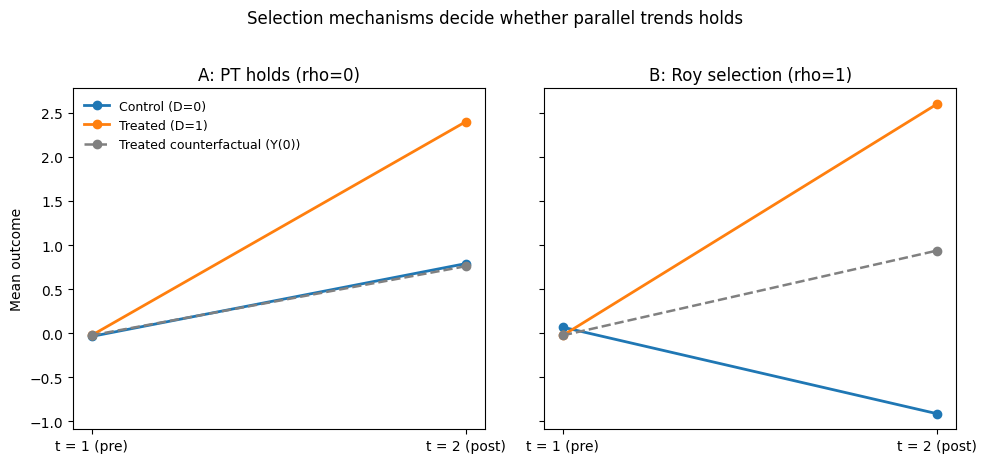

In [5]:
rng_plot = np.random.default_rng(SEED)  # re-anchor for reproducible plot

def draw_for_plot(rho, label, rng):
    dgp = draw_dgp(rho, rng)
    return pd.DataFrame({
        "scenario": label,
        "period":   np.tile([1, 2], N),
        "D":        np.tile(dgp["D"].values[:, None], 2).ravel(order="F")[:2*N][:N*2],
        "y":        np.concatenate([dgp["y_t1"].values, dgp["y_t2"].values]),
        "y0":       np.concatenate([dgp["y0_t1"].values, dgp["y0_t2"].values]),
    })


# Simpler wide-format construction for the plot:
def build_plot_rows(rho, label, rng):
    dgp = draw_dgp(rho, rng)
    df = pd.DataFrame({
        "scenario": [label] * (2 * N),
        "period":   np.concatenate([np.ones(N, dtype=int), 2 * np.ones(N, dtype=int)]),
        "D":        np.concatenate([dgp["D"].values, dgp["D"].values]),
        "y":        np.concatenate([dgp["y_t1"].values, dgp["y_t2"].values]),
        "y0":       np.concatenate([dgp["y0_t1"].values, dgp["y0_t2"].values]),
    })
    return df


plot_df = pd.concat([
    build_plot_rows(0.0, "A: PT holds (rho=0)", rng_plot),
    build_plot_rows(1.0, "B: Roy selection (rho=1)", rng_plot),
], ignore_index=True)

group_means = (plot_df
               .groupby(["scenario", "period", "D"])
               .agg(y_mean=("y", "mean"), y0_mean=("y0", "mean"))
               .reset_index())
group_means["group"] = np.where(group_means["D"] == 1, "Treated (D=1)", "Control (D=0)")

# Treated counterfactual (Y(0) for treated units)
treat_cf = (plot_df[plot_df["D"] == 1]
            .groupby(["scenario", "period"])
            .agg(y0_mean=("y0", "mean"))
            .reset_index())

scenarios = group_means["scenario"].unique()
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

for ax, scen in zip(axes, scenarios):
    gm = group_means[group_means["scenario"] == scen]
    cf = treat_cf[treat_cf["scenario"] == scen]

    for grp, sub in gm.groupby("group"):
        ax.plot(sub["period"], sub["y_mean"], marker="o", linewidth=2.0, label=grp)

    ax.plot(cf["period"], cf["y0_mean"],
            linestyle="--", marker="o", linewidth=1.8,
            color="gray", label="Treated counterfactual (Y(0))")

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["t = 1 (pre)", "t = 2 (post)"])
    ax.set_title(scen)
    ax.set_xlabel("")

axes[0].set_ylabel("Mean outcome")
axes[0].legend(loc="upper left", frameon=False, fontsize=9)

fig.suptitle("Selection mechanisms decide whether parallel trends holds",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Punchline

- **Scenario A.** DiD is ~unbiased. Selection on gains is present in both scenarios, but with $\rho = 0$ the gain-driving factor is independent of the untreated trend, so parallel trends still holds.
- **Scenario B.** DiD is systematically biased. The bias is the *product* of two things:
  1. $\rho > 0$ ties the untreated trend to the gain-driving factor $v$.
  2. Treatment selects units with high $v$.

Remove either ingredient and DiD is unbiased. Ghanem, Sant'Anna & Wüthrich's contribution is to make that joint dependence explicit: PT is a restriction on *how units select into treatment*, not a statement about trends in isolation.

### Reproducibility note

This notebook uses `numpy.random.default_rng(20260421)`, which is NOT bit-identical to R's `set.seed(20260421)`. The retired R simulation and this Python notebook therefore produce different numerical values for every MC statistic. The *qualitative pattern* — A unbiased, B biased, bias grows with $\rho$ — reproduces faithfully.

The retired R simulation is preserved at the `v0-r-era` git tag for anyone who wants to cross-check.